In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unc_tools import serif, FunctionBase1D, UncRegression
import os

DATA_DIR = os.path.join(os.getcwd(), "data")
SAVE_DIR = os.path.join(os.getcwd(), "output")
def savefig(name, path= "", fig=None, bbox_inches = None, **kwargs):
    os.makedirs(SAVE_DIR, exist_ok=True)
    if bbox_inches is None:
        bbox_inches = "tight"
    if fig is None:
        fig = plt.gcf()
    new_path = os.path.join(SAVE_DIR, name)
    fig.savefig(new_path, bbox_inches = bbox_inches, **kwargs)

serif()

In [2]:


df = pd.DataFrame({})

CP_ = np.array([0.005, 0.005, 0.002, 0.002])
CI_ = np.array([0.1, 0.2, 0.2, 0.1])

V0I = np.array([10, 20, 20, 10])
V0P = np.array([5, 5, 5, 5])

CP_ = CP_ * 100 / (100 + V0P)
CI_ = CI_ * 100 / (100 + V0P)

dfR2 = pd.DataFrame({})

CI_, CP_

(array([0.0952381 , 0.19047619, 0.19047619, 0.0952381 ]),
 array([0.0047619 , 0.0047619 , 0.00190476, 0.00190476]))

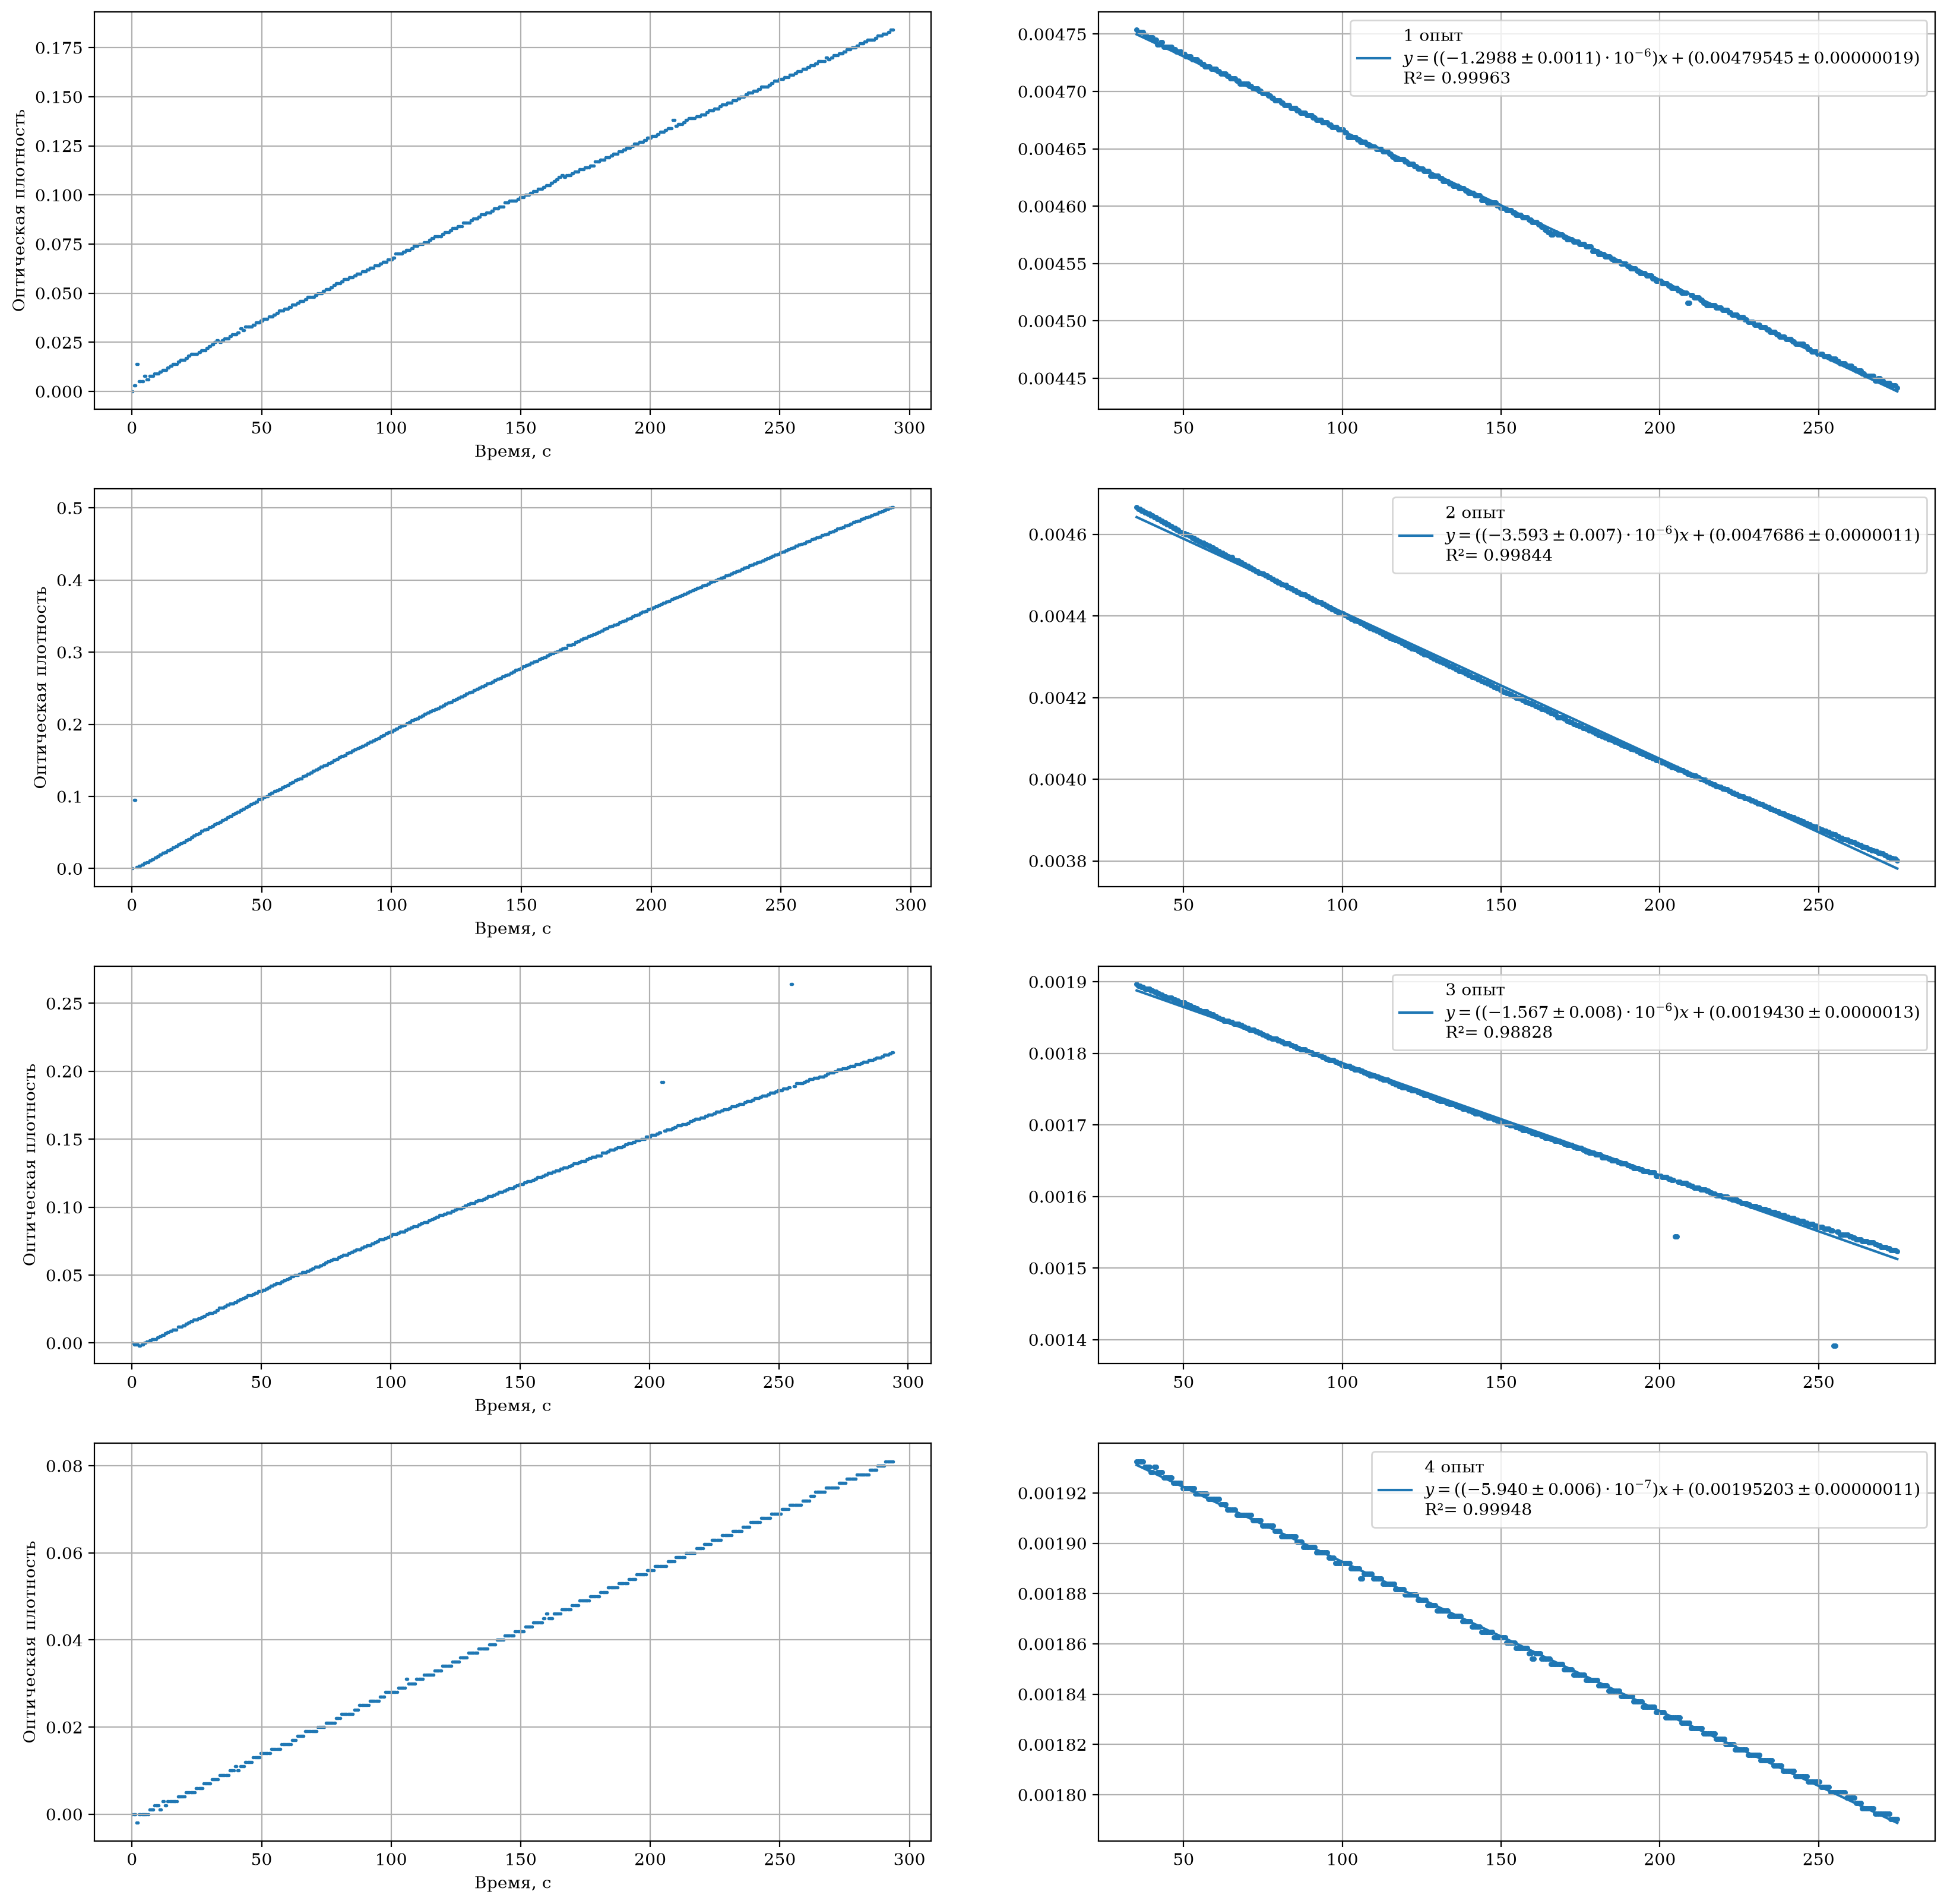

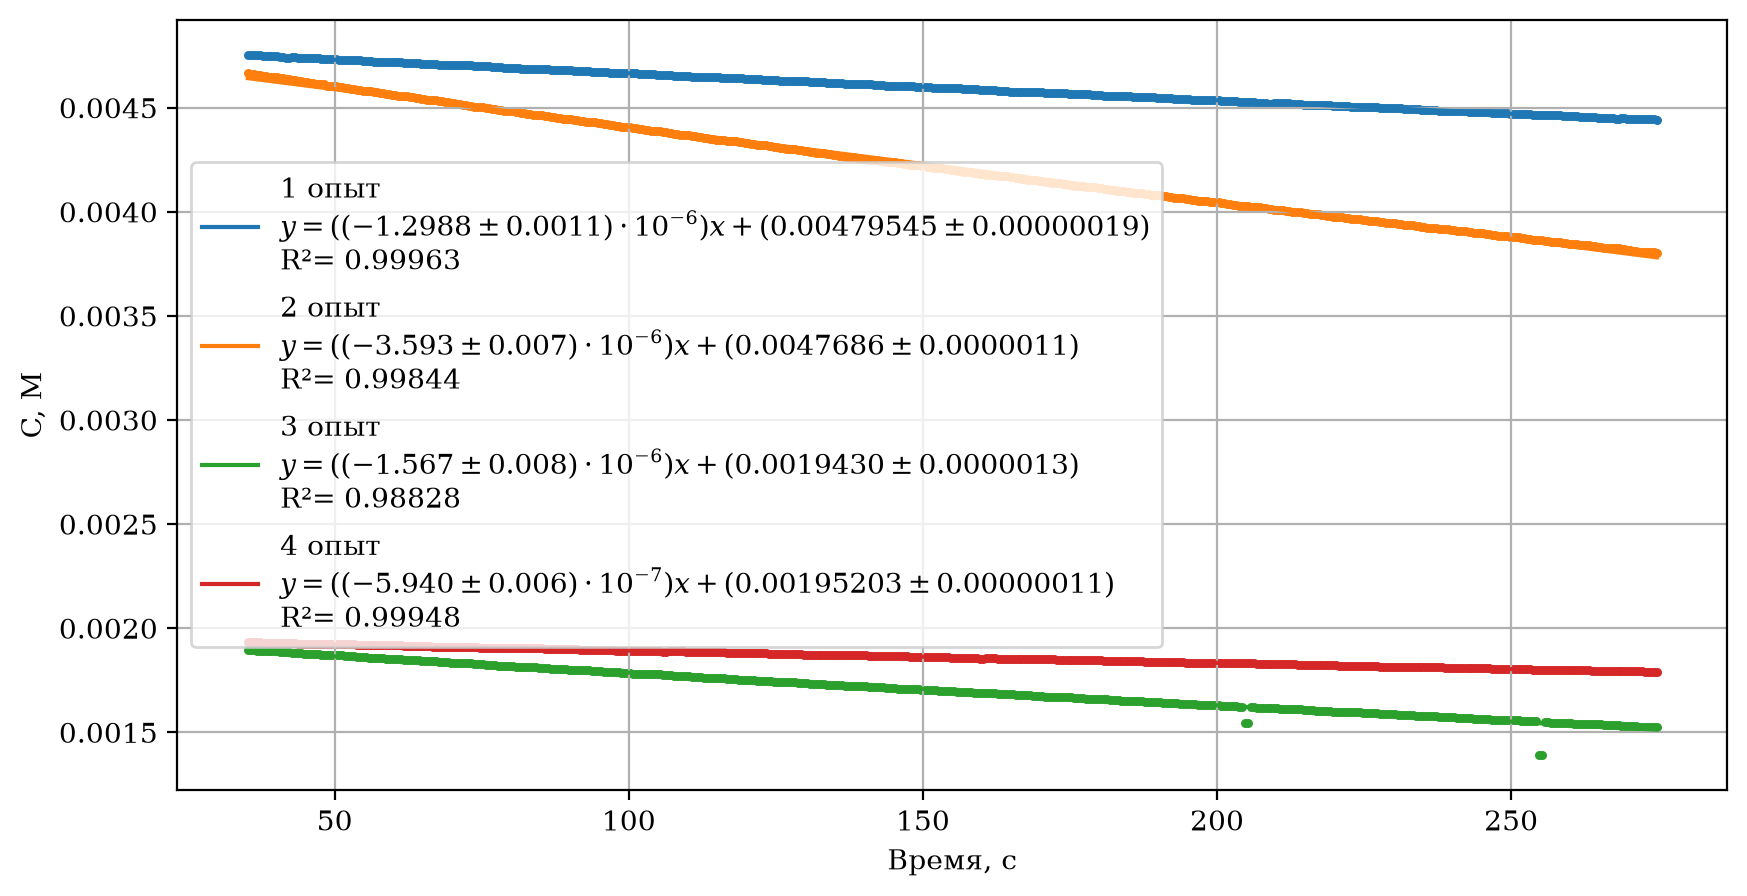

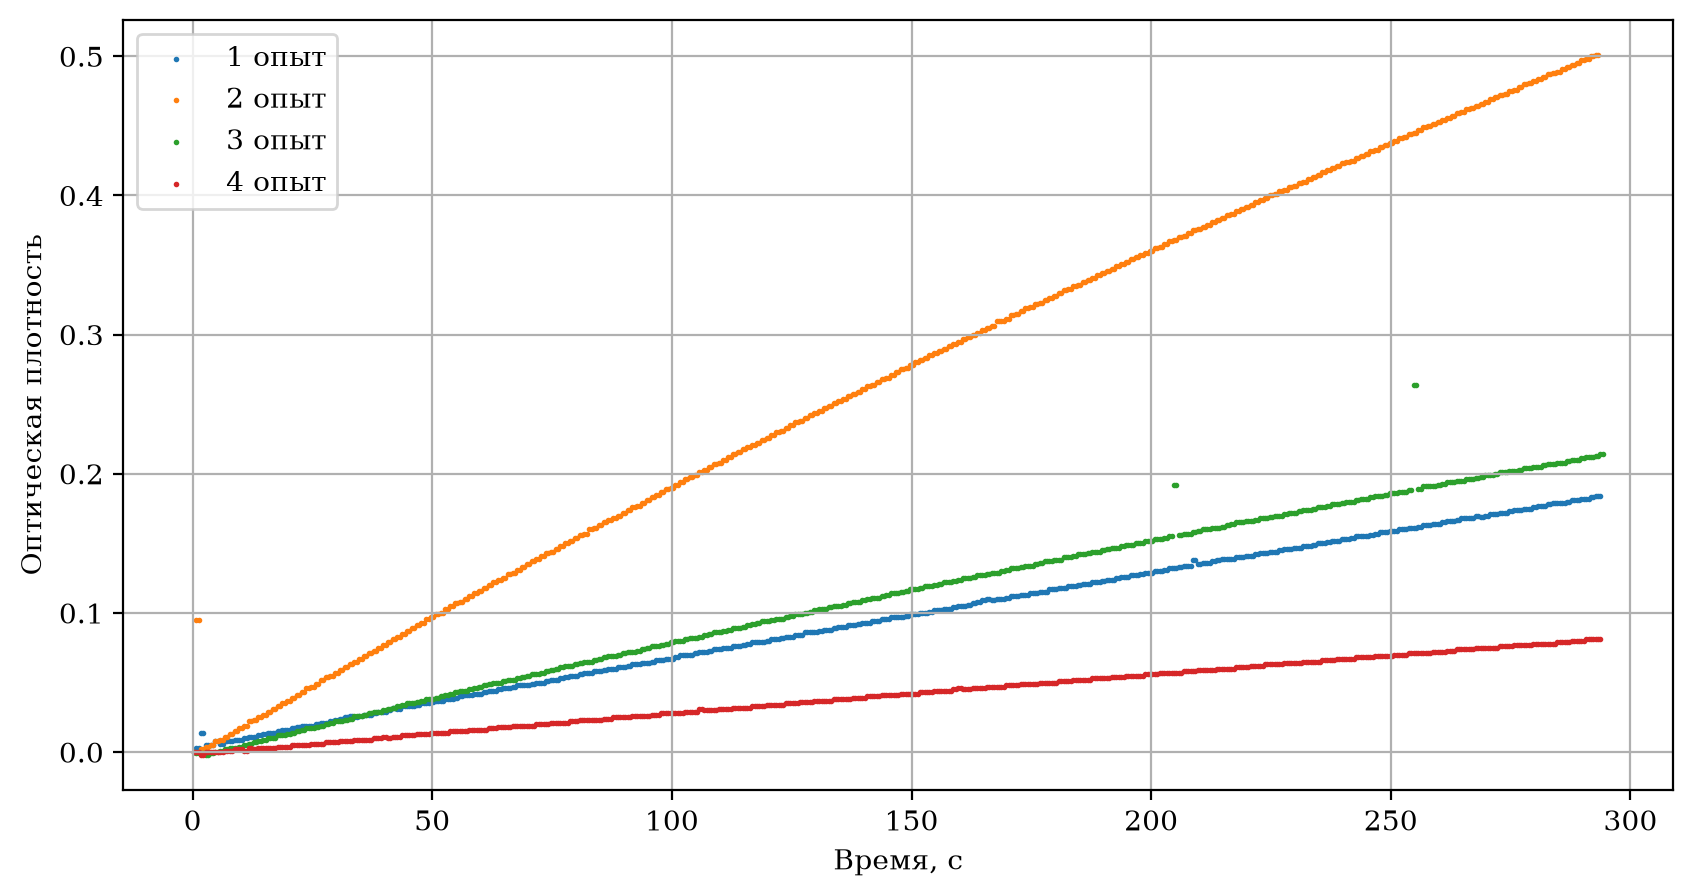

In [3]:
fig1, axes = plt.subplots(4, 2, figsize=(20, 20), dpi=200)

fig2, ax_2 = plt.subplots(figsize=(10, 5), dpi=200)

fig3, ax_3 = plt.subplots(figsize=(10, 5), dpi=200)

coefs = []

for i in range(1, 5):
    with open(os.path.join(DATA_DIR, f"{i}.txt"), "r", errors="replace") as f:
        lines = f.read().splitlines()

        D = []
        time = []
        for j, line in enumerate(lines):
            line = line.split("\t")

            time.append(float(line[0]))
            D.append(float(line[1]))

        ax1 = axes[i - 1][0]
        ax2 = axes[i - 1][1]

        a = slice(70, 550)

        df[f"time{i}"] = time[a]
        df[f"D{i}"] = D[a]

        ax1.scatter(time, D, s=1)
        ax1.grid(True)
        ax1.set_xlabel("Время, с")
        ax1.set_ylabel("Оптическая плотность")

        ax_3.scatter(time, D, s=1, label=f"{i} опыт")
        ax_3.grid(True)
        ax_3.set_xlabel("Время, с")
        ax_3.set_ylabel("Оптическая плотность")
        ax_3.legend()

        df[f"CI{i}"] = (df[f"D{i}"] - 0.0220877) / 471.19218526
        df[f"CP{i}"] = CP_[i - 1] - df[f"CI{i}"]

        regression = UncRegression(df[f"time{i}"], df[f"CP{i}"])
        regression.plot(ax=ax2, s=5, label=f"{i} опыт")
        regression.plot(ax=ax_2, s=5, label=f"{i} опыт")
        coefs.append(regression.R2)
        ax_2.set_xlabel("Время, с")
        ax_2.set_ylabel("C, М")

dfR2["zero"] = coefs

savefig("zero-order-graphs-prak1", fig=fig1, bbox_inches="tight")
savefig("zero-order-graph-prak1", fig=fig2, bbox_inches="tight")
savefig("experiment-prak1", fig=fig3, bbox_inches="tight")

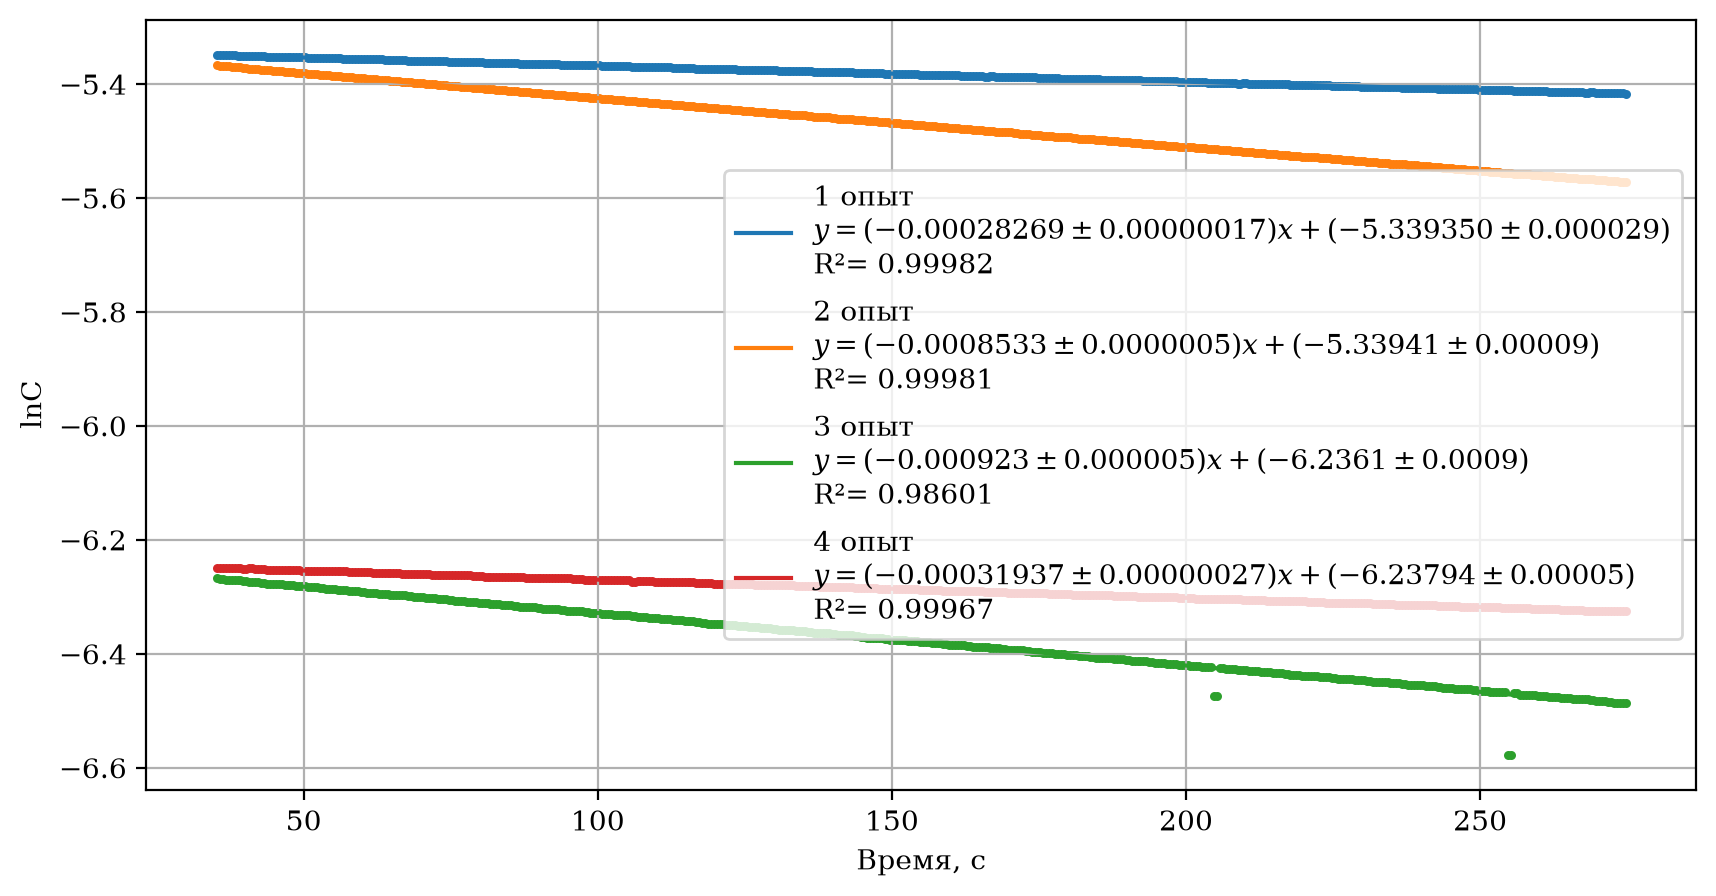

In [4]:
coefs = []

fig2, ax_2 = plt.subplots(figsize=(10, 5), dpi=200)

for i in range(1, 5):
    with open(os.path.join(DATA_DIR, f"{i}.txt"), "r", errors="replace") as f:
        lines = f.read().splitlines()

        D = []
        time = []
        for j, line in enumerate(lines):
            line = line.split("\t")

            time.append(float(line[0]))
            D.append(float(line[1]))

        a = slice(70, 550)

        df[f"time{i}"] = time[a]
        df[f"D{i}"] = D[a]

        df[f"CI{i}"] = (df[f"D{i}"] - 0.0220877) / 471.19218526
        df[f"CP{i}"] = CP_[i - 1] - df[f"CI{i}"]

        regression = UncRegression(df[f"time{i}"], np.log(df[f"CP{i}"]))
        # regression = UncRegression(df[f"time{i}"], df[f"CP{i}"], FunctionBase1D("a*ln(x) + b"))
        regression.plot(ax=ax_2, s=5, label=f"{i} опыт")
        coefs.append(regression.R2)
        ax_2.set_xlabel("Время, с")
        ax_2.set_ylabel("lnC")

dfR2["one"] = coefs

savefig("one-order-graph-prak1", fig = fig2, bbox_inches="tight")

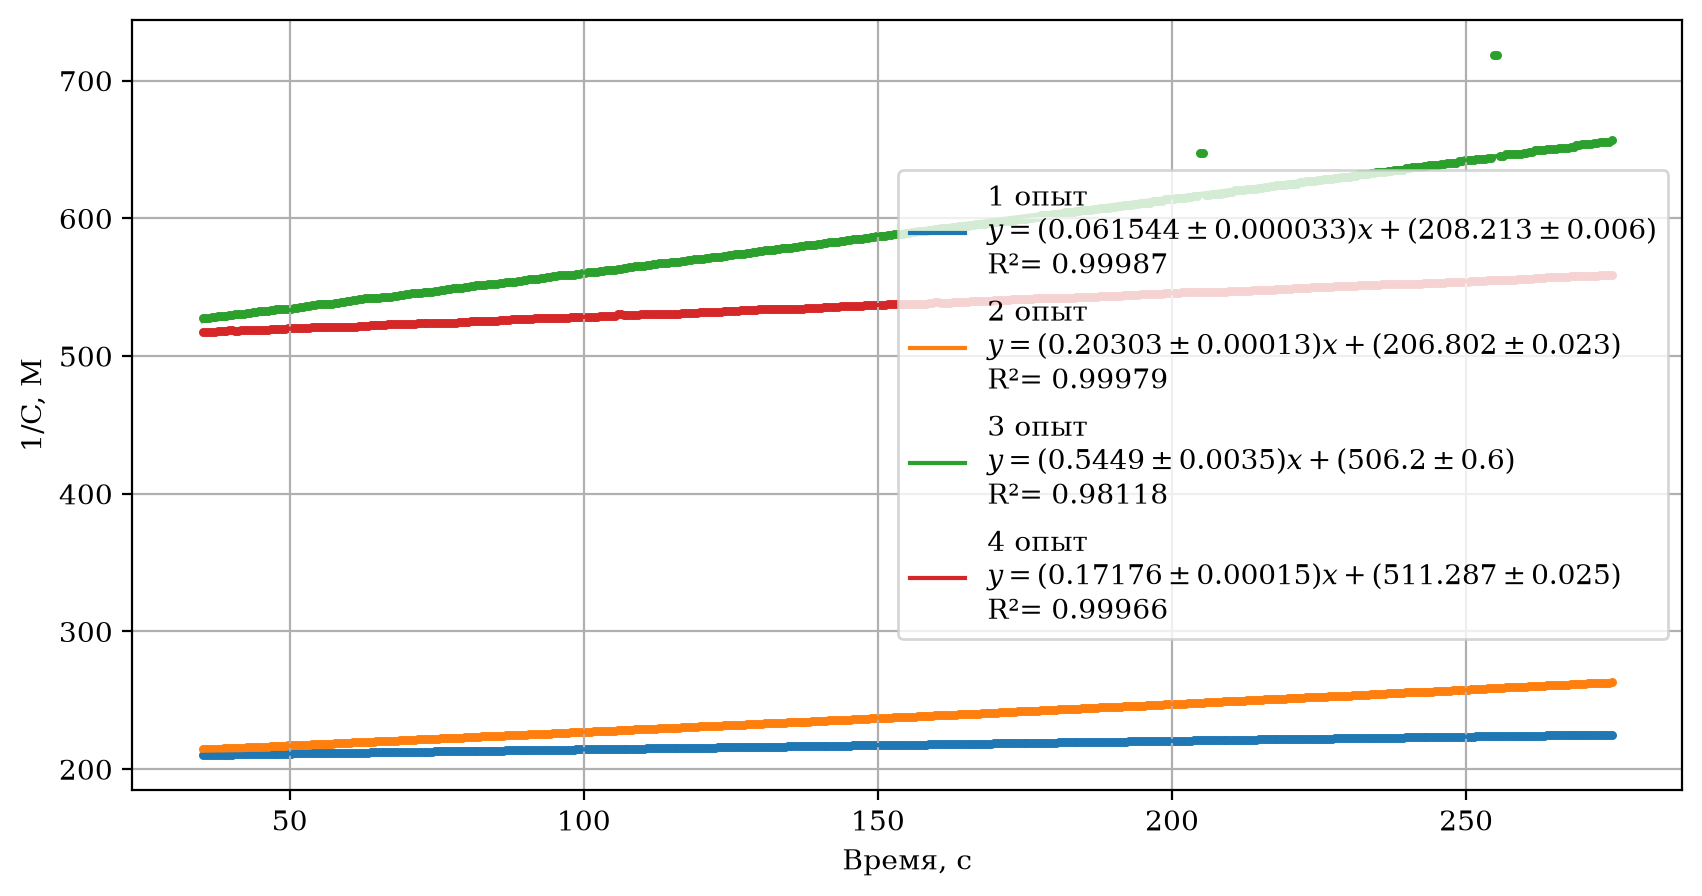

In [5]:
coefs = []

fig2, ax_2 = plt.subplots(figsize=(10, 5), dpi=200)

for i in range(1, 5):
    with open(os.path.join(DATA_DIR, f"{i}.txt"), "r", errors="replace") as f:
        lines = f.read().splitlines()

        D = []
        time = []
        for j, line in enumerate(lines):
            line = line.split("\t")

            time.append(float(line[0]))
            D.append(float(line[1]))

        ax1 = axes[i - 1][0]
        ax2 = axes[i - 1][1]

        a = slice(70, 550)

        df[f"time{i}"] = time[a]
        df[f"D{i}"] = D[a]

        df[f"CI{i}"] = (df[f"D{i}"] - 0.0220877) / 471.19218526
        df[f"CP{i}"] = CP_[i - 1] - df[f"CI{i}"]

        regression = UncRegression(df[f"time{i}"], 1 / (df[f"CP{i}"]))
        regression.plot(ax=ax_2, s=5, label=f"{i} опыт")
        coefs.append(regression.R2)
        ax_2.set_xlabel("Время, с")
        ax_2.set_ylabel("1/C, М")

dfR2["two"] = coefs

savefig("second-order-graph-prak1", fig = fig2, bbox_inches="tight")

In [6]:
dfR2.to_csv(os.path.join(SAVE_DIR, "r2s.csv"))

k = 0.0067+/-0.0007; alpha = 0.89631+/-0.01533; beta = 1.55618+/-0.02027
R2 = 0.99989


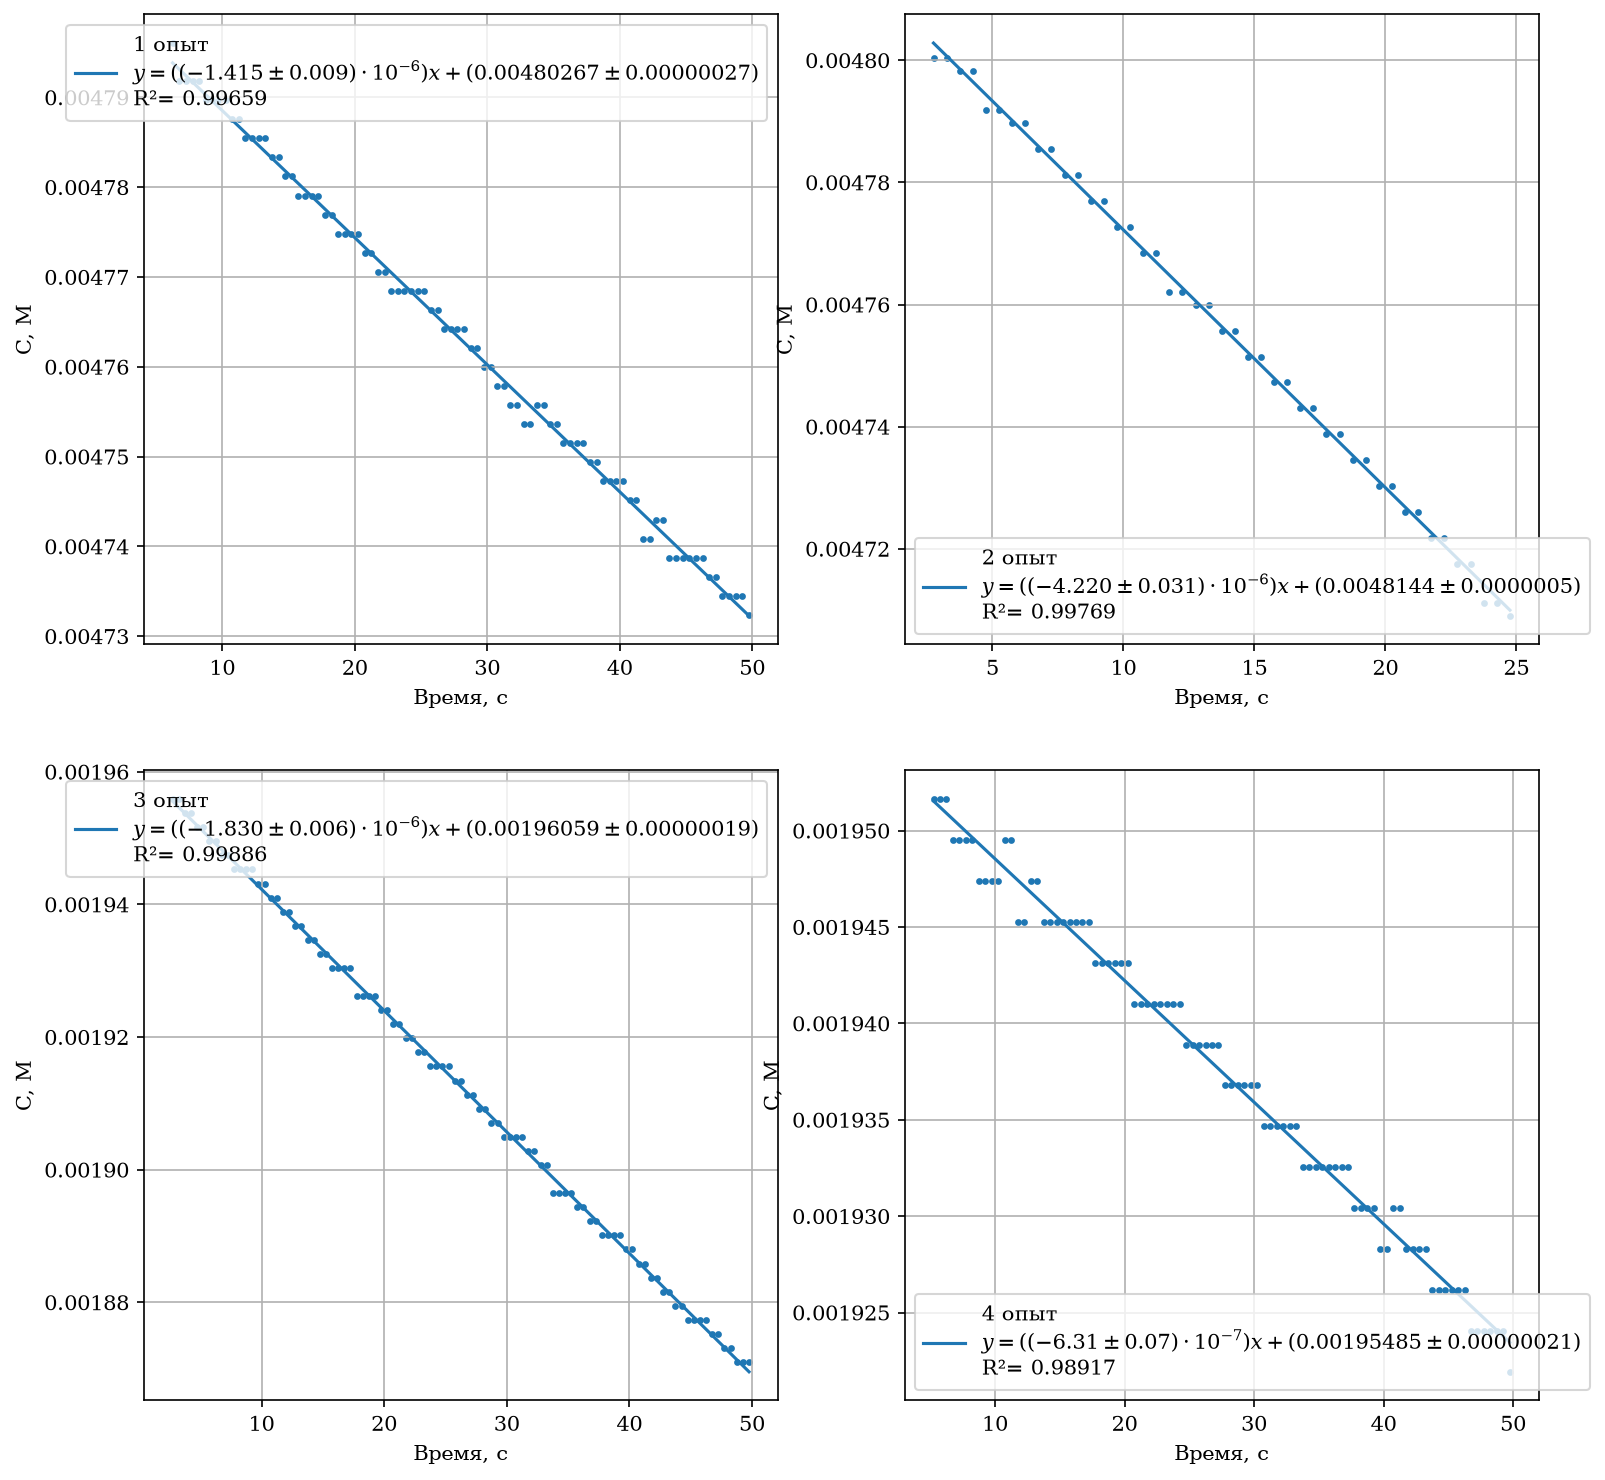

In [7]:
import uncertainties as unc
import uncertainties.unumpy as unp

r0 = []
a = [slice(12, 100), slice(5, 50), slice(5, 100), slice(10, 100)]

fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=150)
axes = axes.flatten()

for i in range(1, 5):
    with open(os.path.join(DATA_DIR, f"{i}.txt"), "r", errors="replace") as f:
        lines = f.read().splitlines()

        D = []
        time = []
        for j, line in enumerate(lines):
            line = line.split("\t")

            time.append(float(line[0]))
            D.append(float(line[1]))

        df = pd.DataFrame({})

        df[f"time{i}"] = time[a[i - 1]]
        df[f"D{i}"] = D[a[i - 1]]

        df[f"CI{i}"] = (df[f"D{i}"] - 0.0220877) / 471.19218526
        df[f"CP{i}"] = CP_[i - 1] - df[f"CI{i}"]

        regression = UncRegression(df[f"time{i}"], (df[f"CP{i}"]))

        ax = axes[i - 1]

        regression.plot(ax=ax, s=5, label=f"{i} опыт")

        r0.append(-regression.coefs[0])

        ax.set_xlabel("Время, с")
        ax.set_ylabel("C, М")

savefig("begin_phase", fig = fig, bbox_inches="tight")

C_m2s2o8 = CP_
C_ki = CI_

r0 = [x.n for x in r0]

X = np.column_stack([C_m2s2o8, C_ki])

def func(x, a, b, c):
    return a + b * np.log(x[:, 0]) + c * np.log(x[:, 1])

reg_multi = UncRegression(X, np.log(r0), func=func)

a = reg_multi.coefs[0]
b = reg_multi.coefs[1]
c = reg_multi.coefs[2]

k = unp.exp(a)
alpha = b
beta = c

print(f"k = {k}; alpha = {alpha:.4u}; beta = {beta:.4u}")
print(f"R2 = {reg_multi.R2:.5f}")
